# Schedule Visualisation

Visual sanity check for `src/schedule_utils.py`:

1. **$\bar{\alpha}_t$ curves** - baseline (shared) vs MI-adjusted (per-K).
2. **MI(t) curves** - these diverge under the baseline schedule and overlap with the $K_{\text{ref}}=2$ reference under the adjusted schedule.
3. **MI vs $\bar{\alpha}$ surface** - with the operating points marked, showing how each cardinality lives on its own curve.

**Key formula** - mutual information between $x_0$ and $x_t$ for a $K$-category feature:

$$I(x_0; x_t) = \log K + p_K \log p_K + (K-1)\, q_K \log q_K$$

where $p_K = \bar{\alpha}_t + \frac{1 - \bar{\alpha}_t}{K}$ and $q_K = \frac{1 - \bar{\alpha}_t}{K}$.

Figures save to `outputs/figures/`.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.schedule_utils import (
    mutual_info_multinomial,
    compute_adjusted_schedules,
)

FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Build the baseline + adjusted schedules

Linear schedule $\beta_t \in [10^{-4},\, 0.02]$, $T = 1000$ (matches the Gaussian schedule).

$$\bar{\alpha}_t = \prod_{s=1}^{t}(1 - \beta_s)$$


In [2]:
T = 1000
betas = np.linspace(1e-4, 0.02, T)
alpha_bars_base = np.cumprod(1.0 - betas)

# Adult cardinalities + the canonical visualisation set the spec asks for.
vis_Ks = [2, 8, 16, 41]
adj = compute_adjusted_schedules(alpha_bars_base, vis_Ks, K_ref=2)

for K in vis_Ks:
    print(f'K={K:>3d}  ᾱ_adj at t=500: {adj[K][500]:.6f}  (base={alpha_bars_base[500]:.6f})')


K=  2  ᾱ_adj at t=500: 0.077797  (base=0.077797)
K=  8  ᾱ_adj at t=500: 0.030258  (base=0.077797)
K= 16  ᾱ_adj at t=500: 0.021009  (base=0.077797)
K= 41  ᾱ_adj at t=500: 0.013251  (base=0.077797)


## 2. $\bar{\alpha}_t$ schedules - baseline vs MI-adjusted

Baseline is a single shared curve. Adjusted curves diverge by $K$ - with $K_{\text{ref}}=2$ the high-K curves sit **below** the baseline (more noise).

**Equalisation condition:** for each feature with cardinality $K_i$, find $\bar{\alpha}_t^{(K_i)}$ such that:

$$I\!\left(\bar{\alpha}_t^{(K_i)},\, K_i\right) = I\!\left(\bar{\alpha}_t^{\text{base}},\, K_{\text{ref}}\right)$$


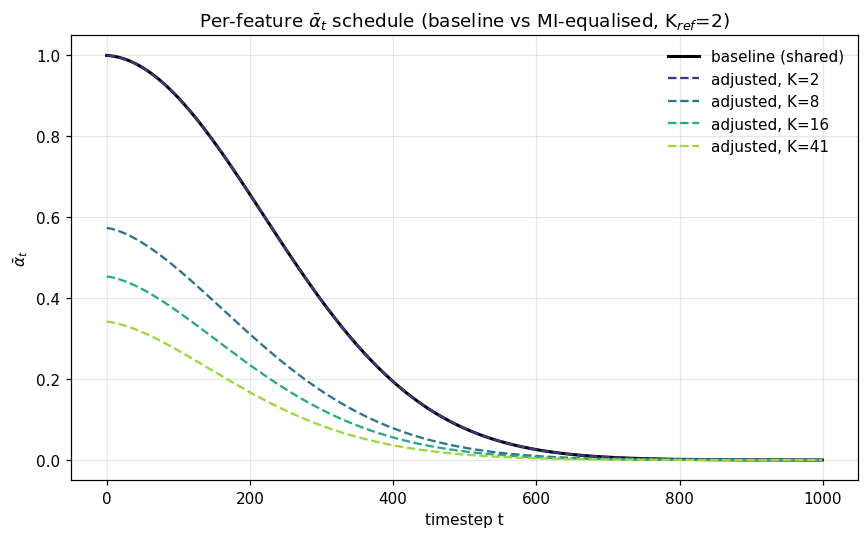

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ts = np.arange(T)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(vis_Ks)))

ax.plot(ts, alpha_bars_base, color='black', lw=2, label='baseline (shared)')
for K, c in zip(vis_Ks, colors):
    ax.plot(ts, adj[K], color=c, lw=1.5, ls='--', label=f'adjusted, K={K}')

ax.set_xlabel('timestep t')
ax.set_ylabel(r'$\bar{\alpha}_t$')
ax.set_title(r'Per-feature $\bar{\alpha}_t$ schedule (baseline vs MI-equalised, K$_{ref}$=2)')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_alpha_bar_schedules.png', bbox_inches='tight')
plt.show()


## 3. MI(t) - does equalisation actually equalise?

Under the **baseline** schedule each cardinality follows its own MI curve (they peak at different $\log K$ values and decay at different rates).

Under the **adjusted** schedule every curve overlaps the $K=2$ reference - that's the definition of MI equalisation. When the dashed lines collapse onto the black reference line, the solver is working correctly.


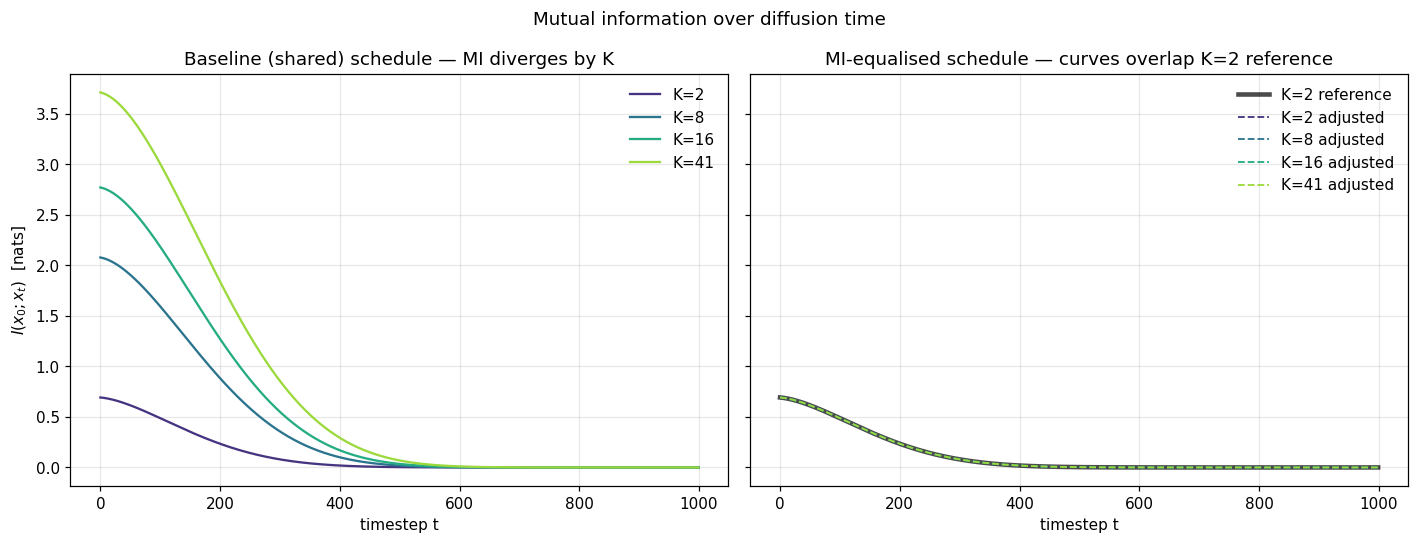

Max |MI(adjusted, K) - MI(base, K_ref=2)| across t:
  K=  2: max err = 0.000e+00   (expected ≈ 0)
  K=  8: max err = 3.576e-11   (expected ≈ 0)
  K= 16: max err = 4.157e-11   (expected ≈ 0)
  K= 41: max err = 4.362e-11   (expected ≈ 0)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left panel: baseline
ax = axes[0]
for K, c in zip(vis_Ks, colors):
    mi = mutual_info_multinomial(alpha_bars_base, K)
    ax.plot(ts, mi, color=c, lw=1.5, label=f'K={K}')
ax.set_xlabel('timestep t')
ax.set_ylabel(r'$I(x_0; x_t)$  [nats]')
ax.set_title('Baseline (shared) schedule - MI diverges by K')
ax.legend(frameon=False, loc='upper right')

# Right panel: adjusted - every curve overlaps the K=2 reference.
ax = axes[1]
mi_ref = mutual_info_multinomial(alpha_bars_base, 2)
ax.plot(ts, mi_ref, color='black', lw=3, label='K=2 reference', alpha=0.7)
for K, c in zip(vis_Ks, colors):
    mi = mutual_info_multinomial(adj[K], K)
    ax.plot(ts, mi, color=c, lw=1.2, ls='--', label=f'K={K} adjusted')
ax.set_xlabel('timestep t')
ax.set_title('MI-equalised schedule - curves overlap K=2 reference')
ax.legend(frameon=False, loc='upper right')

fig.suptitle('Mutual information over diffusion time')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_mi_over_time.png', bbox_inches='tight')
plt.show()

# Quantitative check: max deviation from K=2 reference, under adjusted.
print('Max |MI(adjusted, K) - MI(base, K_ref=2)| across t:')
for K in vis_Ks:
    mi = mutual_info_multinomial(adj[K], K)
    err = np.max(np.abs(mi - mi_ref))
    print(f'  K={K:>3d}: max err = {err:.3e}   (expected ≈ 0)')


## 4. MI vs $\bar{\alpha}$ - operating points

Each $K$ has its own $I(\bar{\alpha})$ curve, rising from 0 at $\bar{\alpha}=0$ to $\log K$ at $\bar{\alpha}=1$. The baseline schedule pushes every feature down the *same* $\bar{\alpha}$ trajectory - but they sit on different curves, so they end up at different MI values.

Equalisation moves each $K$'s operating point left (smaller $\bar{\alpha}$ = more noise) so all features sit at the $K=2$ MI level.


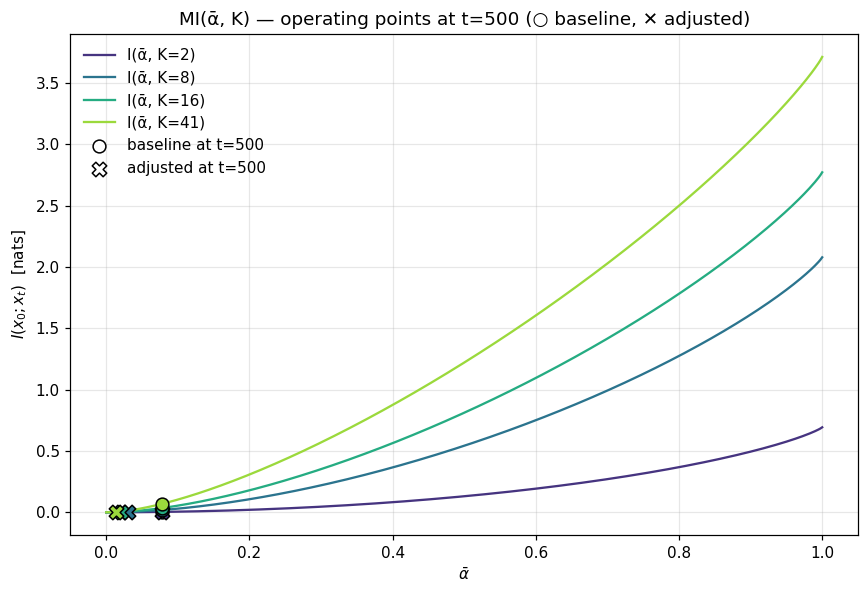

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
ab_grid = np.linspace(0, 1, 400)

for K, c in zip(vis_Ks, colors):
    ax.plot(ab_grid, mutual_info_multinomial(ab_grid, K), color=c, lw=1.5,
            label=f'I(ᾱ, K={K})')

# Mark the operating point at t=500 under each schedule.
t_show = 500
ab_base_t = alpha_bars_base[t_show]
for K, c in zip(vis_Ks, colors):
    mi_base = mutual_info_multinomial(ab_base_t, K)
    mi_adj  = mutual_info_multinomial(adj[K][t_show], K)
    ax.scatter([ab_base_t], [mi_base], color=c, marker='o', s=70,
               edgecolor='black', zorder=5)
    ax.scatter([adj[K][t_show]], [mi_adj], color=c, marker='X', s=90,
               edgecolor='black', zorder=5)

ax.scatter([], [], color='white', marker='o', edgecolor='black', s=70,
           label=f'baseline at t={t_show}')
ax.scatter([], [], color='white', marker='X', edgecolor='black', s=90,
           label=f'adjusted at t={t_show}')
ax.set_xlabel(r'$\bar{\alpha}$')
ax.set_ylabel(r'$I(x_0; x_t)$  [nats]')
ax.set_title(f'MI(ᾱ, K) - operating points at t={t_show} (○ baseline, ✕ adjusted)')
ax.legend(frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_mi_vs_alpha_operating_points.png', bbox_inches='tight')
plt.show()


## Summary

Figures saved:

- `outputs/figures/fig_alpha_bar_schedules.png` - per-K ᾱ schedules.
- `outputs/figures/fig_mi_over_time.png` - MI(t), baseline vs equalised.
- `outputs/figures/fig_mi_vs_alpha_operating_points.png` - MI(ᾱ) surface with the t=500 baseline / adjusted operating points marked.

If the right panel of Figure 2 shows all dashed lines overlapping the black K=2 reference (and the max-err printout is at machine precision), the equalisation solver in `schedule_utils.py` is working correctly.